In [31]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [41]:
data= pd.read_csv(r"C:\Users\admin\Downloads\HR AI Adoption Productivity Final.csv")

In [42]:
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AI_Usage_Level,Uses_AI_Tools,AI_Training_Hours,Productivity_Gain_Percent,AI_Adoption_Sentiment
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,Low,Yes,0 Hours,1-5%,Neutral
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,High,Yes,21-50 Hours,1-5%,Supportive
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,Medium,Yes,0 Hours,6-10%,Neutral
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,Medium,Yes,21-50 Hours,1-5%,Supportive
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,NaN,No,50+ Hours,10%+,Supportive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,5,2,0,3,NaN,No,0 Hours,0%,Supportive
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,3,7,7,1,7,High,Yes,0 Hours,6-10%,Supportive
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,3,6,2,0,3,Low,Yes,50+ Hours,10%+,Resistant
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,2,9,6,0,8,High,Yes,50+ Hours,1-5%,Neutral


In [43]:
df=data.copy()

In [44]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AI_Usage_Level,Uses_AI_Tools,AI_Training_Hours,Productivity_Gain_Percent,AI_Adoption_Sentiment
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,Low,Yes,0 Hours,1-5%,Neutral
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,High,Yes,21-50 Hours,1-5%,Supportive
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,Medium,Yes,0 Hours,6-10%,Neutral
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,Medium,Yes,21-50 Hours,1-5%,Supportive
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,NaN,No,50+ Hours,10%+,Supportive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,5,2,0,3,NaN,No,0 Hours,0%,Supportive
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,3,7,7,1,7,High,Yes,0 Hours,6-10%,Supportive
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,3,6,2,0,3,Low,Yes,50+ Hours,10%+,Resistant
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,2,9,6,0,8,High,Yes,50+ Hours,1-5%,Neutral


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1470 non-null   int64 
 1   Attrition                  1470 non-null   object
 2   BusinessTravel             1470 non-null   object
 3   DailyRate                  1470 non-null   int64 
 4   Department                 1470 non-null   object
 5   DistanceFromHome           1470 non-null   int64 
 6   Education                  1470 non-null   int64 
 7   EducationField             1470 non-null   object
 8   EmployeeCount              1470 non-null   int64 
 9   EmployeeNumber             1470 non-null   int64 
 10  EnvironmentSatisfaction    1470 non-null   int64 
 11  Gender                     1470 non-null   object
 12  HourlyRate                 1470 non-null   int64 
 13  JobInvolvement             1470 non-null   int64 
 14  JobLevel

# DATA CLEANING

In [46]:
tmapping={ '0 Hours':0,
          '21-50 Hours':35,
          '50+ Hours':60,
          '1-20 Hours':11}
df['AI_Training_hours_numeric']=df['AI_Training_Hours'].map(tmapping)
df=df.drop('AI_Training_Hours', axis=1)

In [47]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AI_Usage_Level,Uses_AI_Tools,Productivity_Gain_Percent,AI_Adoption_Sentiment,AI_Training_hours_numeric
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,Low,Yes,1-5%,Neutral,0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,High,Yes,1-5%,Supportive,35
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,Medium,Yes,6-10%,Neutral,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,Medium,Yes,1-5%,Supportive,35
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,NaN,No,10%+,Supportive,60


In [48]:
df['Productivity_Gain_Percent'].unique()

array(['1-5%', '6-10%', '10%+', '0%'], dtype=object)

In [49]:
pmapping={ '1-5%':3,
          '6-10%':8,
          '10%+':10,
          '0%':0}
df['Productivity_gain_%']=df['Productivity_Gain_Percent'].map(pmapping)
df=df.drop('Productivity_Gain_Percent', axis=1)

In [57]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Uses_AI_Tools,AI_Adoption_Sentiment,AI_Training_hours_numeric,Productivity_gain_%,AI_Usage_Level_Numeric
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,Yes,Neutral,0,3,1.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,Yes,Supportive,35,3,2.0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,Yes,Neutral,0,8,3.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,Yes,Supportive,35,3,3.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,No,Supportive,60,10,NaN


In [52]:
df['AI_Usage_Level'].unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

In [53]:
umapping={ 'nan':0,
          'Low':1,
          'High':2,
          'Medium':3}
df['AI_Usage_Level_Numeric']=df['AI_Usage_Level'].map(umapping)
df=df.drop('AI_Usage_Level', axis=1)

In [58]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Uses_AI_Tools,AI_Adoption_Sentiment,AI_Training_hours_numeric,Productivity_gain_%,AI_Usage_Level_Numeric
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,Yes,Neutral,0,3,1.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,Yes,Supportive,35,3,2.0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,Yes,Neutral,0,8,3.0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,Yes,Supportive,35,3,3.0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,No,Supportive,60,10,NaN


In [64]:
df['AI_Usage_Level_Numeric'].fillna('0', inplace=True)

In [65]:
df['AI_Usage_Level_Numeric'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Name: AI_Usage_Level_Numeric, Length: 1470, dtype: bool

In [74]:
df['AI_Usage_Level_Numeric']=df['AI_Usage_Level_Numeric'].astype(int)

# ANALYSIS

# Which Department Are effectively adopting AI tools?

In [69]:
ai_adoption_dept=(df.groupby('Department')['Uses_AI_Tools'].value_counts(normalize=True)
                   .unstack().fillna(0)*100)
ai_adoption_dept

Uses_AI_Tools,No,Yes
Department,,
Human Resources,23.809524,76.190476
Research & Development,21.748179,78.251821
Sales,21.524664,78.475336


# Insights :
-AI adoption is strong across departments with sales and R&D leading slightly , while HR Reprsents the biggest opprounity for targeted AI Capability
enhancement 
- AI adoption is highest in sales with 78.47% likely using for forecasting , Crm Insights and customer targeting.
- The same % is followed by R$D separtment indicates strong use of AI in research , analysis . 
- HR is slightly lower but strong indicating usage of Ai for screeing and ATS 

# Policy can be implemented 
-Implement department-specific AI rollout strategies

# Does AI usage actually improve productivity?

In [70]:
df.groupby('Uses_AI_Tools')['Productivity_gain_%'].mean()

Uses_AI_Tools
No     5.237500
Yes    5.162609
Name: Productivity_gain_%, dtype: float64

# Insights :
-Employee Not using AI average productivity gain is 5.24% and Employee Using AI average productivity gain is 5.16% which means.

   -Ai usage does not show a clear productivity advantage respective to this dataset.

   -This suggests ai adapation is happening but notbeing used effecively.


# Policy can be implemented 

-Shift the focus from Ai adoption to Ai effectiveness 
  - Train employee on how to apply ai to real job task not just toll access. 

-Role-Specific AI training 
  - For HR, R&D etc 

-Audit Ai usage patterns 
  - identify whether Ai is being used for copying and basic research.

# How does AI usage intensity affect productivity?

In [75]:
df.groupby('AI_Usage_Level_Numeric')['Productivity_gain_%'].mean()

AI_Usage_Level_Numeric
0    5.237500
1    5.130864
2    5.214984
3    5.155251
Name: Productivity_gain_%, dtype: float64

# Insights:
0,1,2,3 is none , low , high , medium and the data again speakes about zero clear productivity advantage with respective dataset 
- Totaly implies AI intensity is not equal to Ai effectiveness 

# Policy can be implemented 
- Introduce task based AI gudilines 
- Skill based AI Training 

# Is AI training a key driver of productivity gains?

In [77]:
df[['AI_Training_hours_numeric', 'Productivity_gain_%']].corr()

,AI_Training_hours_numeric,Productivity_gain_%
AI_Training_hours_numeric,1.000000,-0.014619
Productivity_gain_%,-0.014619,1.000000


# Insights:
- Correlation between Ai training and productivity gains is -0.014 which is nearly zero 
- which implies no meaningful relationship between Ai training hours and the productivity gain 
- Training may be too genric , not applied on real task .

# Policy can be implemented 
- Redesign Ai training Programs : From theory based to hands on.
- Post training Accountability : Track employees real workflow after Ai usage and implementation.
- Department specific Ai learning
- Measure Performace impact after training 

# Does AI adoption reduce employee attrition risk?

In [79]:
pd.crosstab( df['Uses_AI_Tools'],df['Attrition'],normalize='index')*100

Attrition,No,Yes
Uses_AI_Tools,,
No,86.875000,13.125000
Yes,83.043478,16.956522


# Insights:
- Non AI users left are 13.1% where as  AI users Left company are 17% Which indicates that Ai user have high attrition rate.
- Ai adoption does not reduce attrution risk.
- Ai skilled employees are  more marketable. 

# Policy can be implemented 
- Do not treat AI doption as a retention strategy: Ai is not keeping employee longer 
- Recognition for Ai driven contribution 
- Role clarity after Ai adoption 

# Are we losing high-paid employees despite investment?

In [85]:
losing = (df.groupby('Department').agg (average_income=('MonthlyIncome', 'mean'), 
          attrition_rate=('Attrition',lambda x: (x =='Yes').mean()*100)).sort_values(by='attrition_rate', ascending=False))
losing

,average_income,attrition_rate
Department,,
Sales,6959.172646,20.627803
Human Resources,6654.507937,19.047619
Research & Development,6281.252862,13.839750


# Insights: 
- High Investment in salary does not guarantee low attrition non montery factor as role stress, growth opportunities and workculture siginificantly 
influence employee retention 
- The highest attrition happened in the field of Sales which is alos the highest paid shows despite strong compensation , sales is losing employee 

# Policy can be implemented 
- Introduce performace based inccentives instead constant pressure 
- Track engagement and job satisfaction metric not just salary 
- Use Department specific retenion policies instead one approach

# Which workforce segments resist AI adoption?

In [86]:
ai_resistance_segments = df[(df['Uses_AI_Tools'] == 'No')&(df['AI_Adoption_Sentiment'].isin(['Negative', 'Neutral']))]
ai_resistance_segments.groupby('Department').size().sort_values(ascending=False)

Department
Research & Development    95
Sales                     43
Human Resources            5
dtype: int64

# Insights : 
- Ai resistance is mostly in research and department sector which implies the this resistance may occurs due to authencity and trust as
Ai can be threat to creativity and expertise 
- Ai is also more likely resisted in sales may be due the complexcity tools or ROI 
- Hr appears to be open to Ai which clearly state use for screening , reproting and analytics 


# Policy can be implemented 
- Ai should be a Support tool not replacement 
- Run Expert led demos 
- Keep Ai Practical and Fast 
- Measure adoption success by usage not training hours 

# Does AI uasage reflect in performance ratings?

In [87]:
df.groupby('Uses_AI_Tools')['PerformanceRating'].mean()

Uses_AI_Tools
No     3.137500
Yes    3.158261
Name: PerformanceRating, dtype: float64

# Insights: 
-While AI tool users show marginally higher performance ratings, the difference is minimal, suggesting that AI adoption alone is insufficient 
to significantly improve employee performance.

# Is AI delivering Value relative to efforts ?
- Direct financial ROI is not avaiable :productivity impact is measured using proxy indicators 

In [88]:
roi= df.groupby('AI_Usage_Level_Numeric').agg(avg_productivity_gain=('Productivity_gain_%', 'mean'),avg_training_hours=('AI_Training_hours_numeric', 'mean'))
roi

,avg_productivity_gain,avg_training_hours
AI_Usage_Level_Numeric,,
0,5.237500,26.868750
1,5.130864,27.293827
2,5.214984,26.439739
3,5.155251,26.764840


# insights: 
- Increased AI usage and training do not currently translate into higher productivity gains, suggesting low or delayed return on AI investment.
- Training hours are similar across all groups
- ROI from AI investment appears weak

# Policy can be implemented 
-  redefine of Ai usage 
- high impact of Ai usage 
- Task-level AI use cases (reports, analysis, automation)
- Focus on where AI saves time or improves outcomes

# Does AI usage level clearly impact productivity gain?

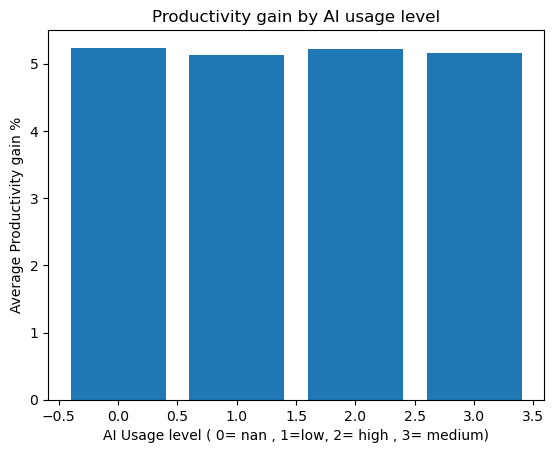

In [91]:
a= df.groupby('AI_Usage_Level_Numeric')['Productivity_gain_%'].mean()
plt.figure()
plt.bar(a.index , a.values)
plt.xlabel('AI Usage level ( 0= nan , 1=low, 2= high , 3= medium)')
plt.ylabel ('Average Productivity gain %')
plt.title('Productivity gain by AI usage level')
plt.show ()

# Insights :
-Employee Not using AI average productivity gain is 5.24% and Employee Using AI average productivity gain is 5.16% which means.

   - Ai usage does not show a clear productivity advantage respective to this dataset.

   - This suggests ai adapation is happening but notbeing used effecively.


# Data Overview 
- Dataset Size :1,470 employees 
- Domain focused : 
    - Demographics
    - Job & Compensation 
    - Perfromace & Attrition
    - AI Adoption & Sentiment


# Executive Summary 
This project studied the AI adoption of employee on the HR level where we evaluated it's impact on 'Performance' , 'Attrition' , 'Return of Investment' 
arcoss the three Departments . And the object of this project is to access the measurable workforce benefits of Ai investment plusy to identify the
areas of risk and opprunity 

# Key Findings : 
- AI Adoption Vs Performance 
  - The different of using AI tools is marginally higher but that does not showed that only AI is driving siginficant to improve performace wheres 
    it does implies Ai tools are present but are mt deeply embedded into Performance improvement .
- Productivity and ROI 
  - Average productivity remain largely flat despite the high training hours in all the level of Ai usage therfore the increases AI training 
    have not resulted in propotional prpductivity gains, suggesting weak or delayed ROI from AI investment 
- Department Level Attrition Risk 
  - Apart form having higher income the avident result of attrition implies the inefficiency in human capital investment.
    Final investment in talent is not being matched by retention outcomes in some department 
- Ai Resistance Concentration
  - Employee who do not use Ai or have netural /negarive sentiments are concerntrated into R&D< Sales department ,
    Resistance is strongest in business critical department , posing a risk of future Ai scalability and effectiveness.
- Training Effectiveness Gap 
  - Ai training is more of appears compliance driven than outcome driven . 
    Ai training hurs relatively uniform across the employee group without meaningful outcomes . 

# Policy Recomandations 
- Shift to outcome- driven AI strategy 
- Redesign AI training Programs 
- Addrss AI Resistance Proactively 
- Strengthen ROI Measurment 
- Retention Focused AI investment 

# Conclusion 
AI adoption is underway which implementation has not yet delivered  meaningful productivity , proformance gain where we can identify real ROI. 
Which should directs the organization to shift Ai adoption towrads trageted otcomes , outcome driven integration supported by effective training and 
change management

In [ ]:
# About Dataset
The dataset captures Ai adoption at high level but lacks task level and workflow specific markers limiting the ability to fully
measure the true effectivness and ROI of AI usage 